In [283]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPool2D,Flatten
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer


data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [285]:
df.shape

(569, 31)

In [286]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [287]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [288]:
#sns.pairplot(df)

In [289]:
x=df.drop("target" , axis = 1)
y=df["target"]

x_train , x_test  ,  y_train , y_test =  train_test_split(x,y , random_state=2 , stratify=y , test_size=0.2)
print( x_train.shape , x_test.shape , y_train.shape , y_test.shape )

(455, 30) (114, 30) (455,) (114,)


In [290]:
from sklearn.preprocessing import StandardScaler
std = StandardScaler()

x_train = std.fit_transform(x_train)
x_test = std.transform(x_test)

In [291]:
y.value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [292]:
model = Sequential()

model.add(Flatten(input_shape = (30,)))

model.add(Dense( 30 , activation="relu"))

model.add(Dense( 20 , activation="relu"))

model.add(Dense( 2 , activation="sigmoid"))

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [293]:
model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_20 (Flatten)            │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 20)             │           620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 2)              │            42 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,592 (6.22 KB)

 Trainable params: 1,592 (6.22 KB)

 Non-trainable params: 0 (0.00 B)

In [294]:
model.compile(optimizer="adam" , loss ="sparse_categorical_crossentropy" , metrics=["accuracy"]) 

In [295]:
history = model.fit( x_train , y_train , batch_size=20 ,epochs= 10, validation_split=0.1 )

Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4197 - loss: 0.9961 - val_accuracy: 0.5217 - val_loss: 0.7485
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6897 - loss: 0.5868 - val_accuracy: 0.8478 - val_loss: 0.5000
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8648 - loss: 0.3949 - val_accuracy: 0.8696 - val_loss: 0.3528
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9075 - loss: 0.2895 - val_accuracy: 0.9130 - val_loss: 0.2634
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9465 - loss: 0.2013 - val_accuracy: 0.9130 - val_loss: 0.2182
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9467 - loss: 0.1551 - val_accuracy: 0.9130 - val_loss: 0.1898
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9564 - loss: 0.1200 - val_accuracy: 0.9130 - val_loss: 0.1653
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9715 - loss: 0.1011 - val_accuracy: 0.9130 - val_loss:

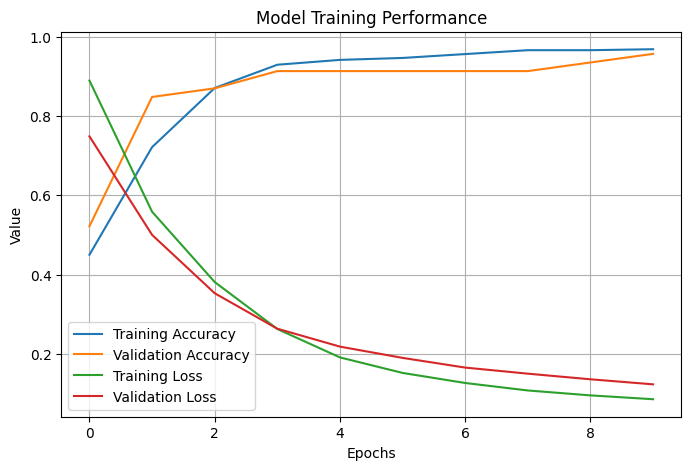

In [296]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Value")
plt.title("Model Training Performance")

plt.legend()
plt.grid(True)
plt.show()

MODEL ACCURACY


In [297]:
loss , accuracy = model.evaluate(x_test , y_test)

print(accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9801 - loss: 0.0762 
0.9736841917037964


In [301]:
y_pred = model.predict(x_test)

print(y_pred[0]) # will give two prob i.e one for class 0 and one for class 2

print(np.argmax(y_pred[0]))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
[0.9667642  0.04394894]
0


In [ ]:
print(y_pred) # again here we get two probabilities for each class

[[9.66764212e-01 4.39489409e-02]
 [7.13902414e-02 9.12196159e-01]
 [1.15454800e-01 8.40290248e-01]
 [9.08335894e-02 9.18751955e-01]
 [1.38093248e-01 8.08406651e-01]
 [3.17773521e-01 7.09708810e-01]
 [4.64426503e-02 8.88468683e-01]
 [6.33665770e-02 8.56469750e-01]
 [4.89251390e-02 9.14848566e-01]
 [6.27906471e-02 8.57627988e-01]
 [9.55538809e-01 4.11721878e-02]
 [9.53320265e-01 6.47281036e-02]
 [5.22246957e-02 9.25111473e-01]
 [1.46267995e-01 8.33434880e-01]
 [9.95457828e-01 3.19634844e-03]
 [4.14529622e-01 6.07003212e-01]
 [4.56818901e-02 9.51320171e-01]
 [9.68669206e-02 9.22720551e-01]
 [1.74642101e-01 8.28501940e-01]
 [4.99251425e-01 7.27052987e-01]
 [6.87263608e-01 5.43064773e-01]
 [9.73075211e-01 2.82012690e-02]
 [9.44510579e-01 2.73180194e-02]
 [2.17415228e-01 8.50733340e-01]
 [1.19755603e-01 8.56731474e-01]
 [1.22206472e-01 9.00539756e-01]
 [9.07960773e-01 1.15725465e-01]
 [9.72057700e-01 1.78318415e-02]
 [4.20971930e-01 7.04135418e-01]
 [9.71883237e-02 9.07870293e-01]
 [1.928634

In [ ]:
y_pred_label = [ np.argmax(i) for i in y_pred ] #argmax give the index of the position where the max number is present
print(y_pred_label)

[0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1]


PREDECTIVE SYSTEM

In [307]:
input_data = [
    17.99, 10.38, 122.80, 1001.0, 0.11840, 0.27760, 0.3001, 0.14710, 0.2419, 0.07871,
    1.095, 0.9053, 8.589, 153.40, 0.006399, 0.04904, 0.05373, 0.01587, 0.03003, 0.006193,
    25.38, 17.33, 184.60, 2019.0, 0.1622, 0.6656, 0.7119, 0.2654, 0.4601, 0.11890
]

input_data_array = np.asarray(input_data)

input_data_array_reshaped =input_data_array.reshape(1,-1)

input_data_array_reshaped_scaled = std.transform(input_data_array_reshaped)

y_pred_input_data = model.predict(input_data_array_reshaped_scaled)

print(y_pred_input_data)

print(np.argmax(y_pred_input_data))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
[[9.9857473e-01 4.2983063e-04]]
0


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [309]:
df.tail(15)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
554,12.880,28.92,82.50,514.3,0.08123,0.05824,0.061950,0.02343,0.1566,0.05708,...,35.74,88.84,595.7,0.12270,0.16200,0.24390,0.06493,0.2372,0.07242,1
555,10.290,27.61,65.67,321.4,0.09030,0.07658,0.059990,0.02738,0.1593,0.06127,...,34.91,69.57,357.6,0.13840,0.17100,0.20000,0.09127,0.2226,0.08283,1
556,10.160,19.59,64.73,311.7,0.10030,0.07504,0.005025,0.01116,0.1791,0.06331,...,22.88,67.88,347.3,0.12650,0.12000,0.01005,0.02232,0.2262,0.06742,1
557,9.423,27.88,59.26,271.3,0.08123,0.04971,0.000000,0.00000,0.1742,0.06059,...,34.24,66.50,330.6,0.10730,0.07158,0.00000,0.00000,0.2475,0.06969,1
558,14.590,22.68,96.39,657.1,0.08473,0.13300,0.102900,0.03736,0.1454,0.06147,...,27.27,105.90,733.5,0.10260,0.31710,0.36620,0.11050,0.2258,0.08004,1
559,11.510,23.93,74.52,403.5,0.09261,0.10210,0.111200,0.04105,0.1388,0.06570,...,37.16,82.28,474.2,0.12980,0.25170,0.36300,0.09653,0.2112,0.08732,1
560,14.050,27.15,91.38,600.4,0.09929,0.11260,0.044620,0.04304,0.1537,0.06171,...,33.17,100.20,706.7,0.12410,0.22640,0.13260,0.10480,0.2250,0.08321,1
561,11.200,29.37,70.67,386.0,0.07449,0.03558,0.000000,0.00000,0.1060,0.05502,...,38.30,75.19,439.6,0.09267,0.05494,0.00000,0.00000,0.1566,0.05905,1
562,15.220,30.62,103.40,716.9,0.10480,0.20870,0.255000,0.09429,0.2128,0.07152,...,42.79,128.70,915.0,0.14170,0.79170,1.17000,0.23560,0.4089,0.14090,0
563,20.920,25.09,143.00,1347.0,0.10990,0.22360,0.317400,0.14740,0.2149,0.06879,...,29.41,179.10,1819.0,0.14070,0.41860,0.65990,0.25420,0.2929,0.09873,0


In [ ]:
input_data2 = [
    7.760, 24.54, 47.92, 181.0, 0.05263, 0.04362, 0.000000, 0.00000, 0.1587, 0.05884, 0.3857, 1.428,
    2.548, 19.15, 0.007189, 0.004660, 0.0123, 0.0156, 0.0214, 0.0032,
    9.12, 18.45, 62.3, 255.0, 0.0912, 0.0834, 0.0021, 0.0009, 0.178, 0.065
]

input_data2_array = np.asarray(input_data2)

input_data2_array_reshaped =input_data2_array.reshape(1,-1)

input_data2_array_reshaped_scaled = std.transform(input_data2_array_reshaped)

y_pred_input_data2 = model.predict(input_data2_array_reshaped_scaled)

print(y_pred_input_data2)

print(np.argmax(y_pred_input_data2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
[[0.01289039 0.97895813]]
1


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
